--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Learner SignUp DateTime  8558 non-null   object
 1   Opportunity Id           8558 non-null   object
 2   Opportunity Name         8558 non-null   object
 3   Opportunity Category     8558 non-null   object
 4   Opportunity End Date     8558 non-null   object
 5   First Name               8558 non-null   object
 6   Date of Birth            8558 non-null   object
 7   Gender                   8558 non-null   object
 8   Country                  8558 non-null   object
 9   Institution Name         8557 non-null   object
 10  Current/Intended Major   8553 non-null   object
 11  Entry created at         8558 non-null   object
 12  Status Description       8558 non-null   object
 13  Status Code              8558 non-null   int64 
 14  Apply Date        

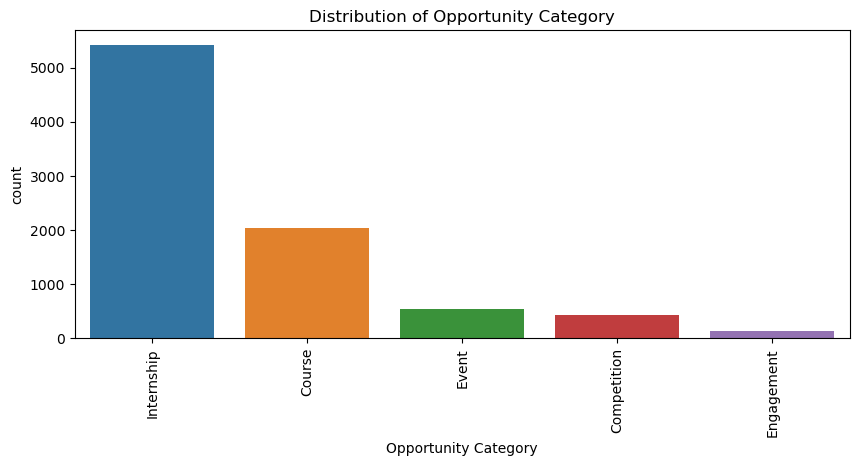

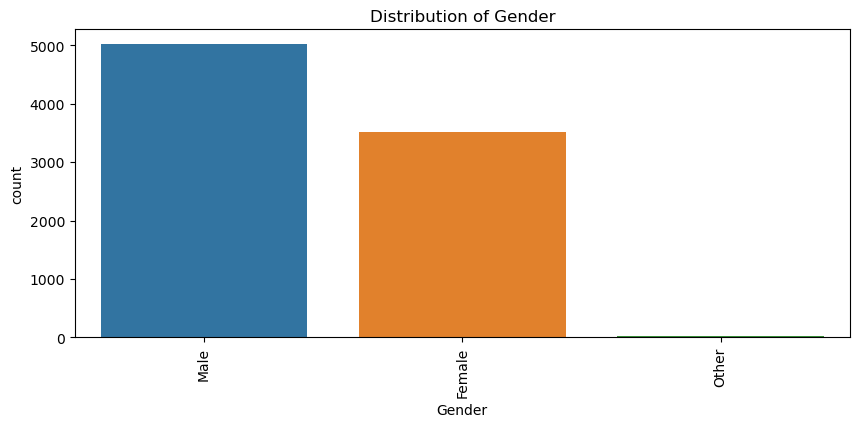

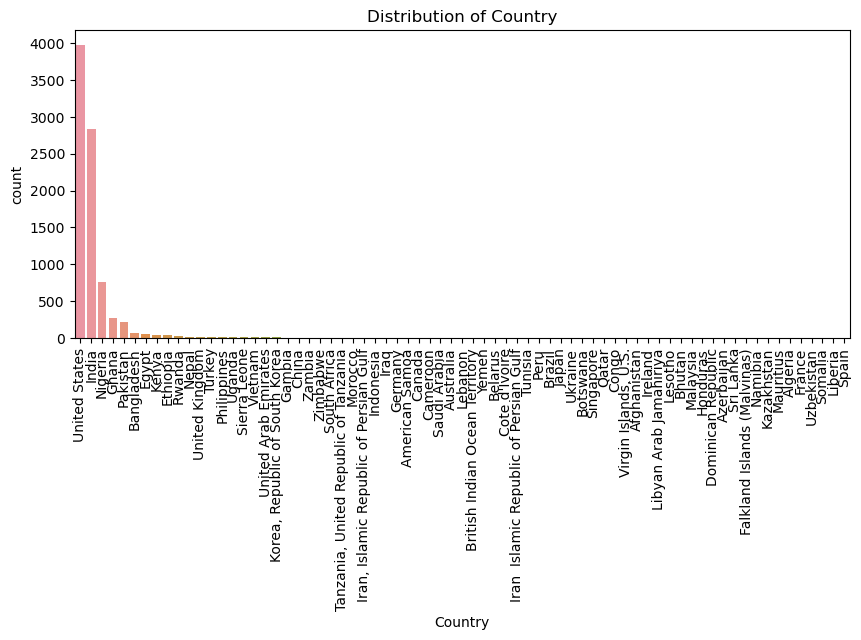

C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:64: UserWarning: Glyph 29664 (\N{CJK UNIFIED IDEOGRAPH-73E0}) missing from current font.
  plt.savefig(f'visualizations/{col}_countplot.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:64: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from current font.
  plt.savefig(f'visualizations/{col}_countplot.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:64: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  plt.savefig(f'visualizations/{col}_countplot.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:64: UserWarning: Glyph 38468 (\N{CJK UNIFIED IDEOGRAPH-9644}) missing from current font.
  plt.savefig(f'visualizations/{col}_countplot.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:64: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from current font.
  plt.savefig(f'visuali

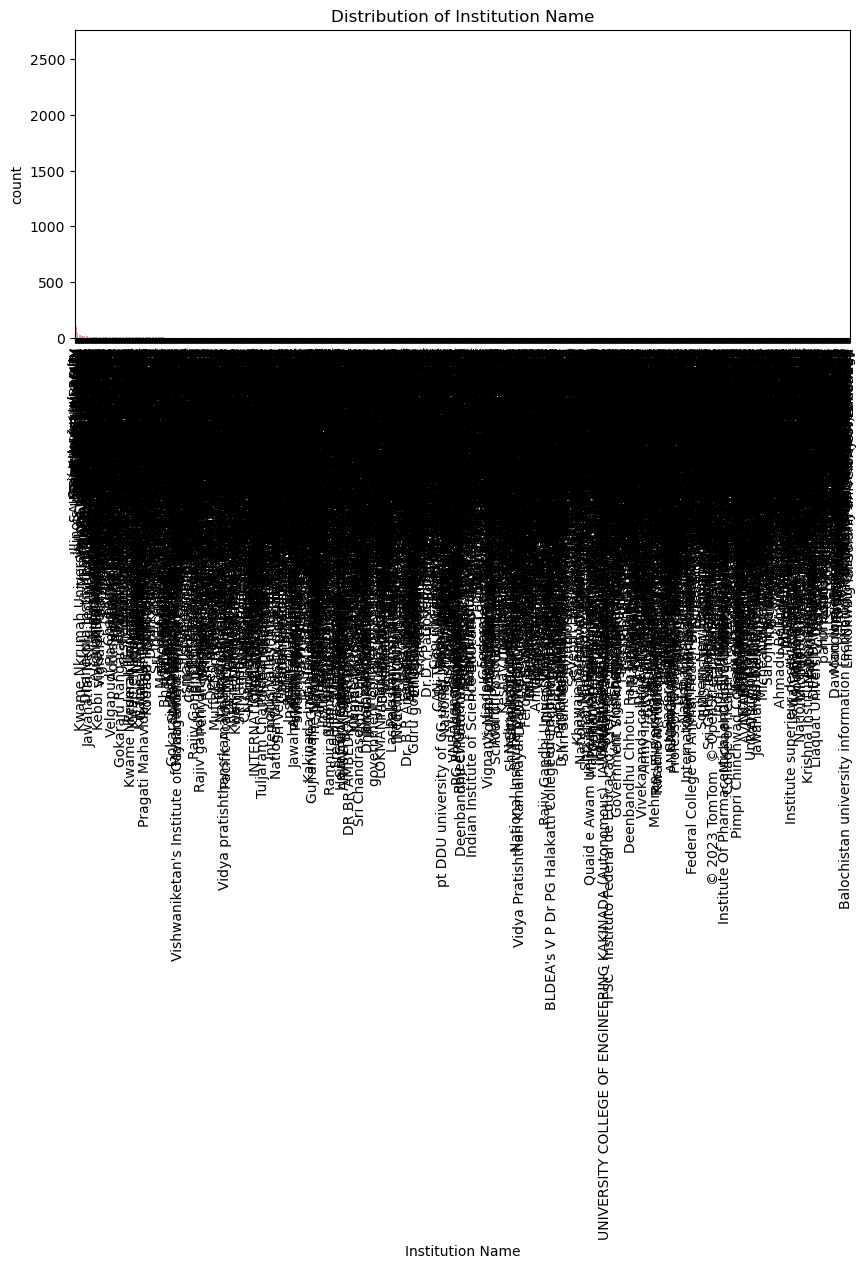

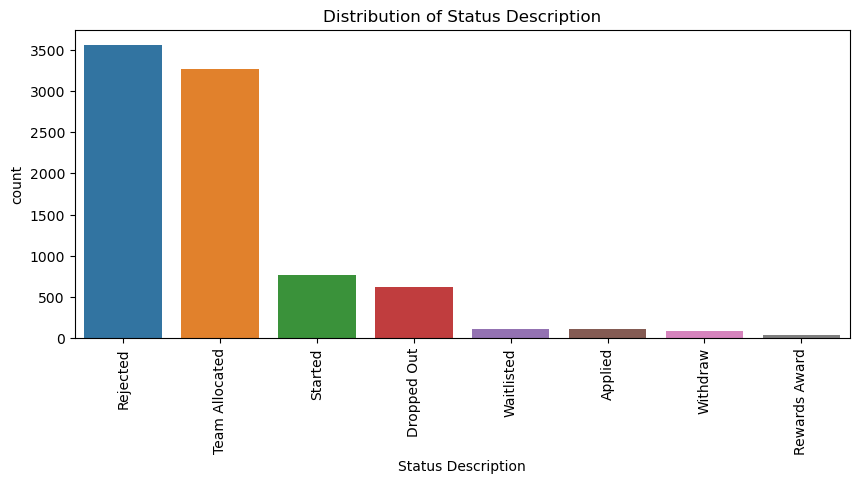

c:\Users\leewa\anaconda3\a cute anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


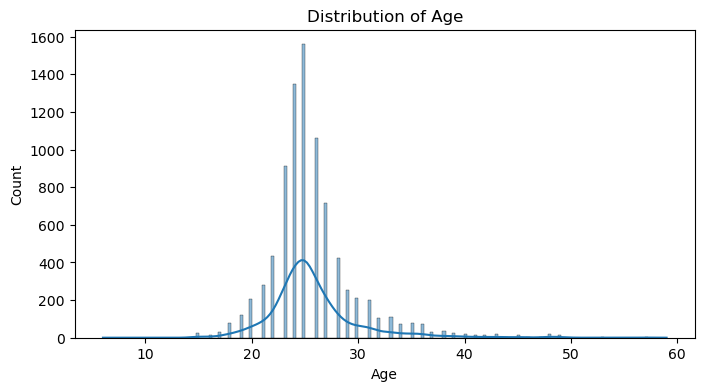

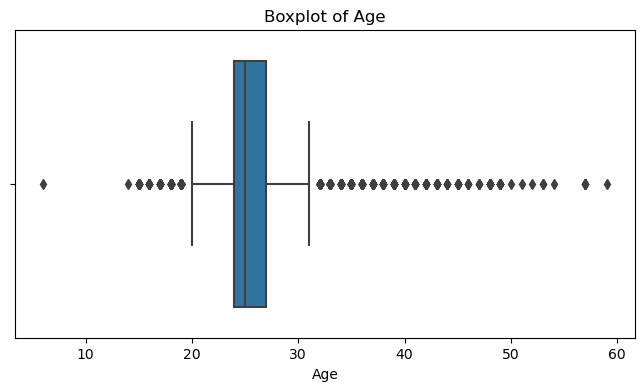

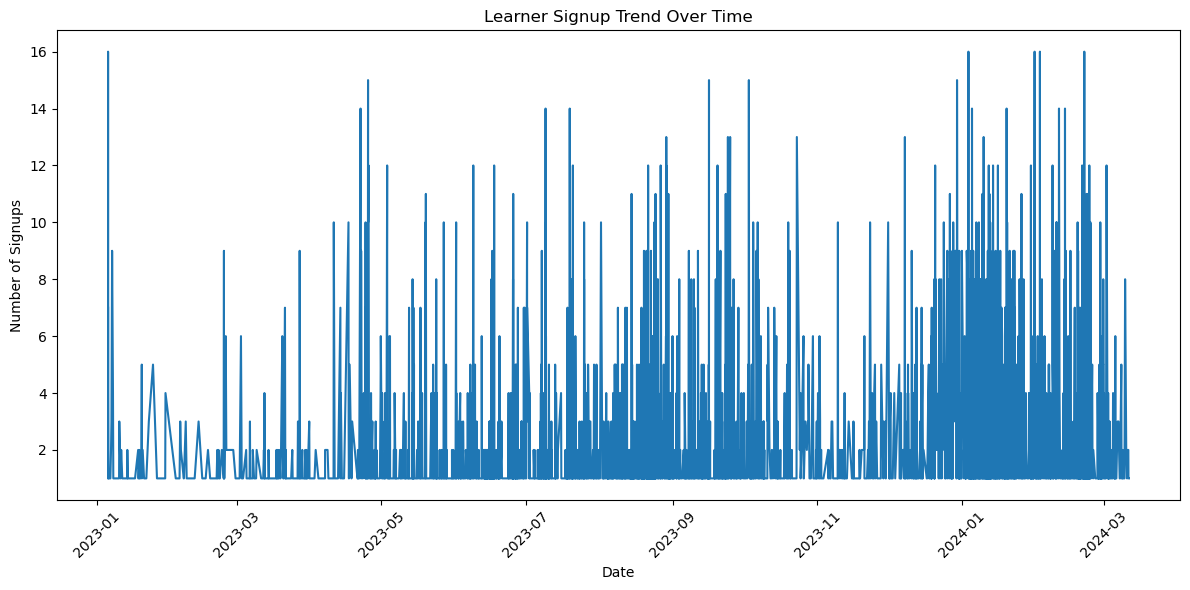

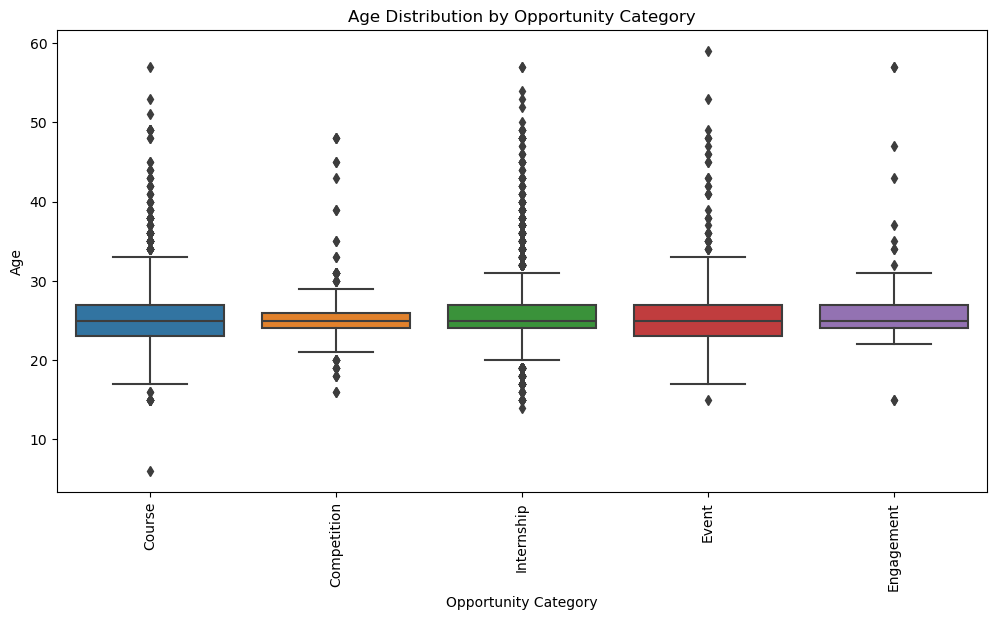

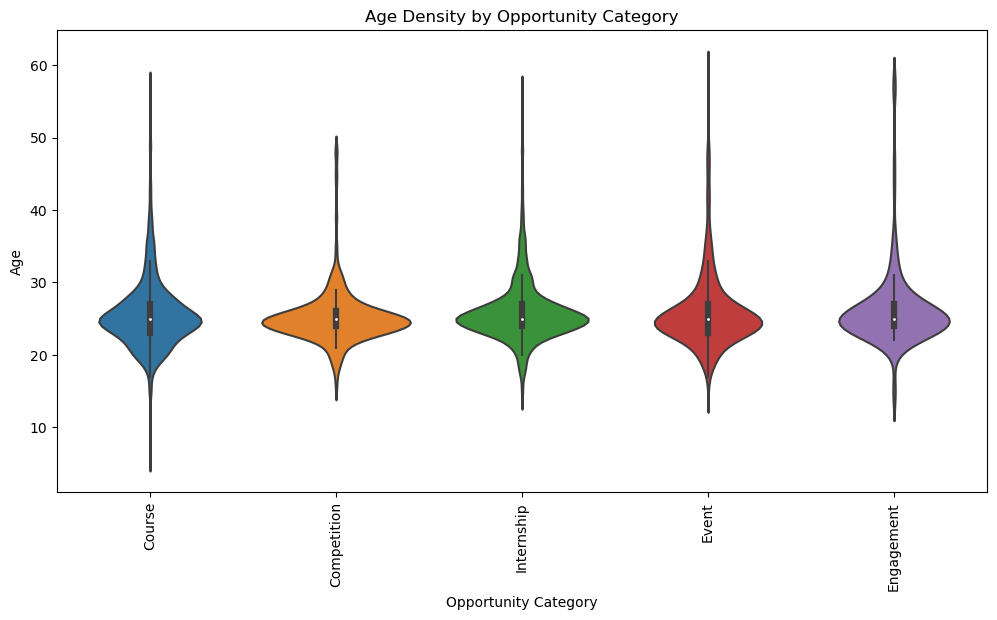

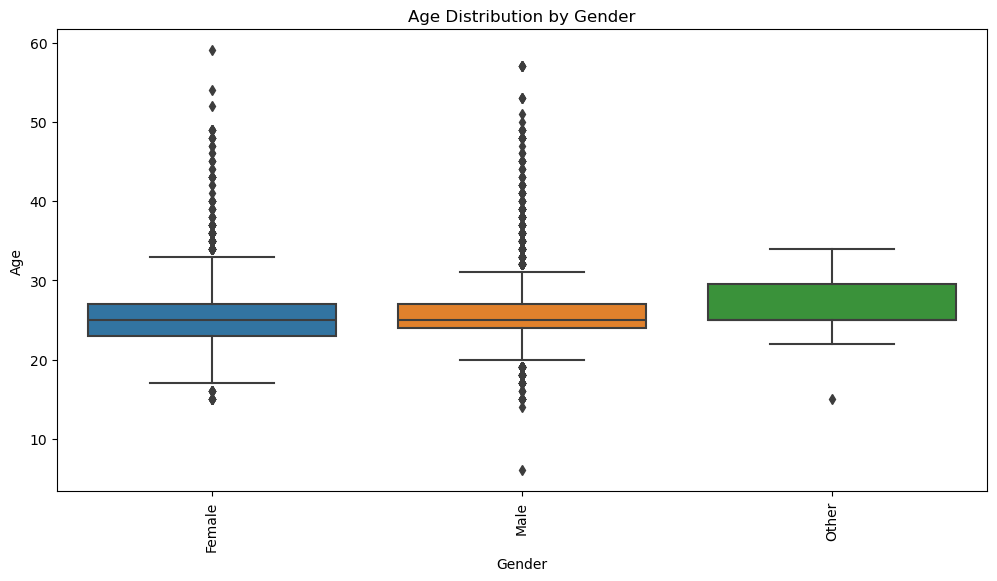

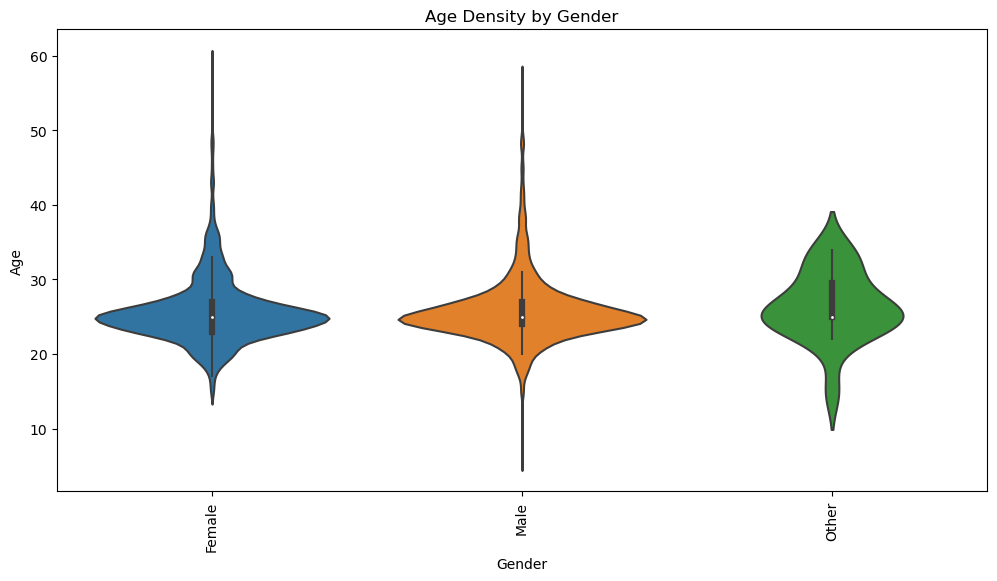

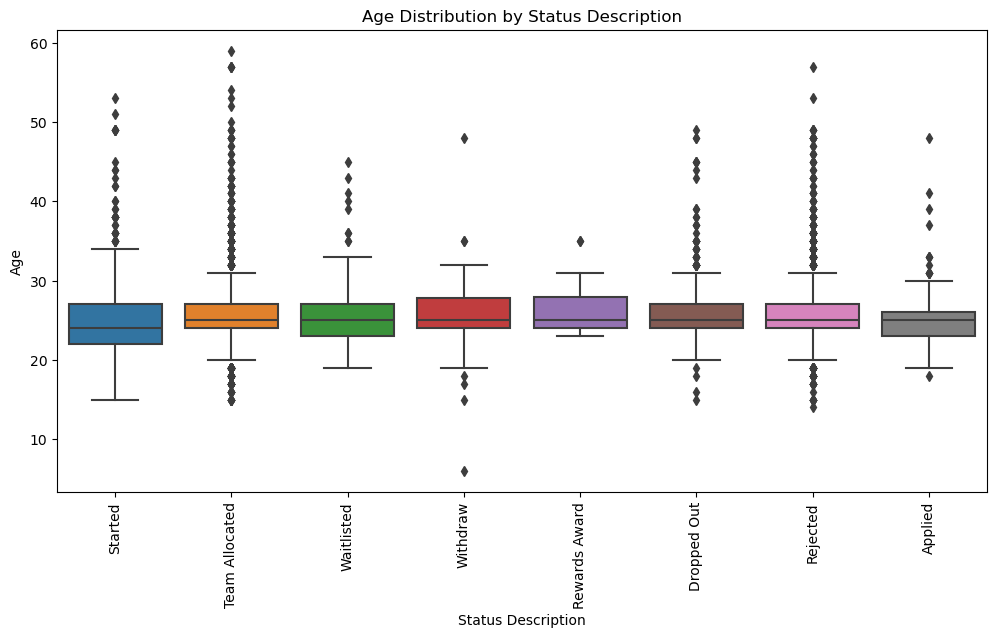

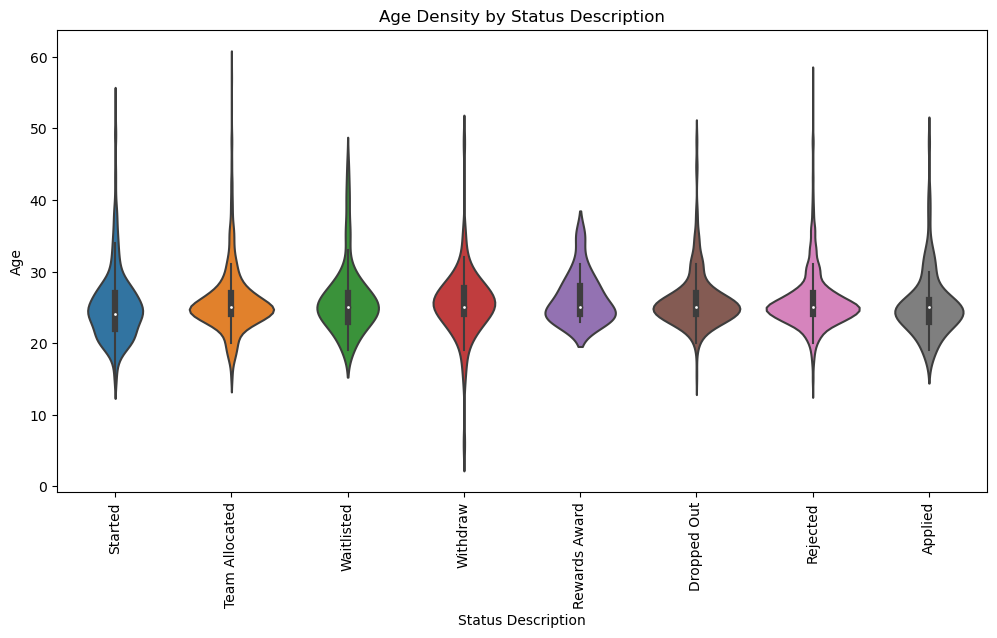

c:\Users\leewa\anaconda3\a cute anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x800 with 0 Axes>

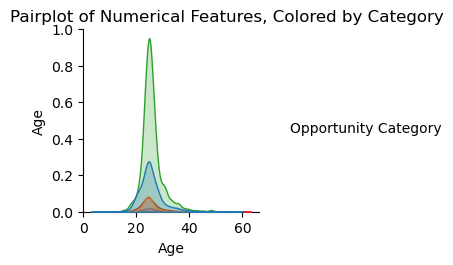

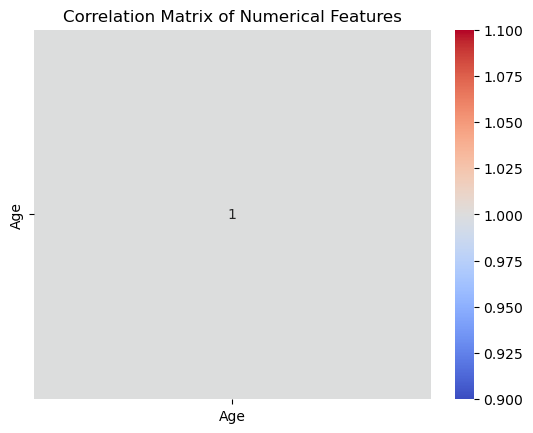

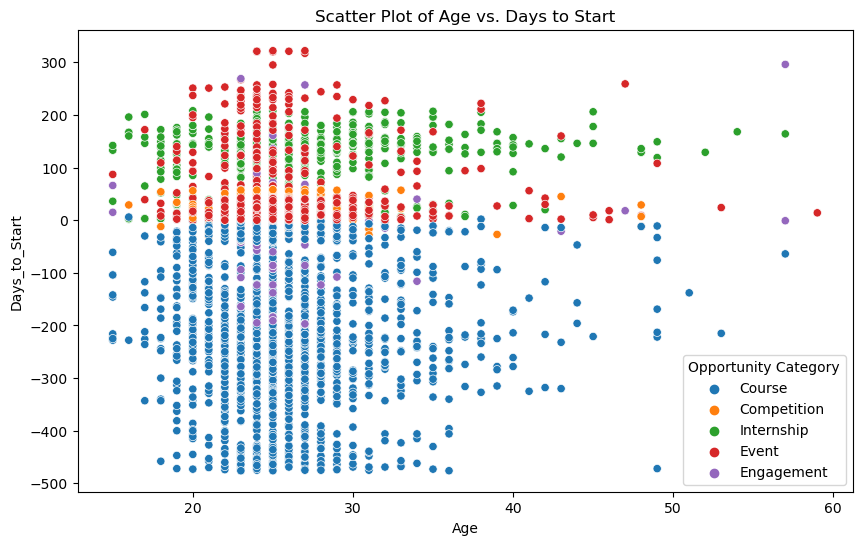

c:\Users\leewa\anaconda3\a cute anaconda\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


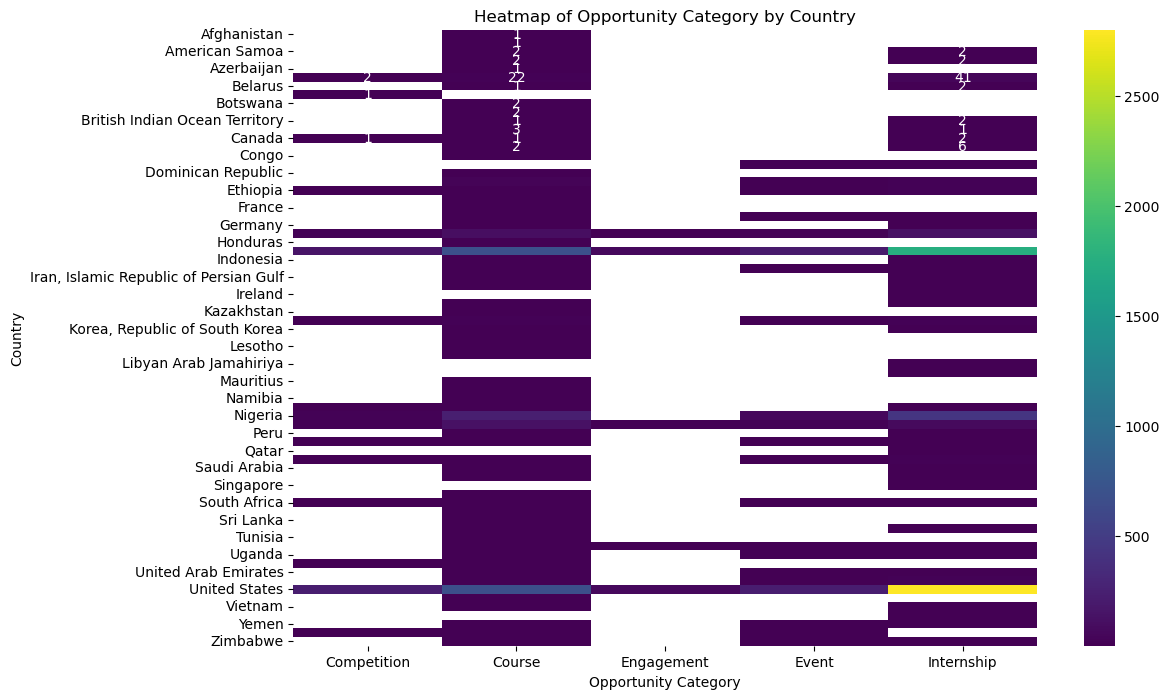

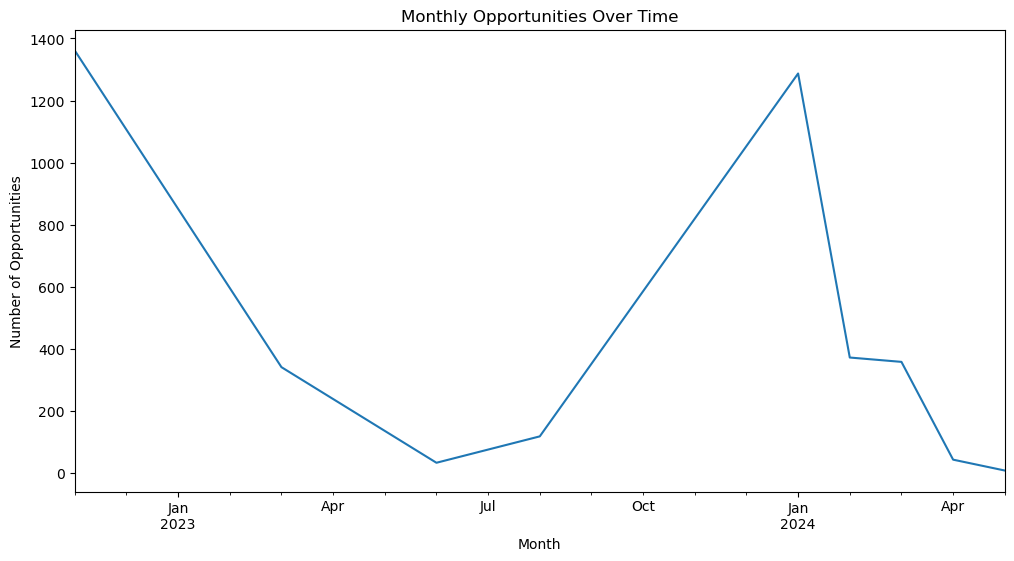

C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:153: UserWarning: Glyph 29664 (\N{CJK UNIFIED IDEOGRAPH-73E0}) missing from current font.
  plt.savefig('visualizations/institution_popularity.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:153: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from current font.
  plt.savefig('visualizations/institution_popularity.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:153: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  plt.savefig('visualizations/institution_popularity.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:153: UserWarning: Glyph 38468 (\N{CJK UNIFIED IDEOGRAPH-9644}) missing from current font.
  plt.savefig('visualizations/institution_popularity.png')
C:\Users\leewa\AppData\Local\Temp\ipykernel_14896\3363975078.py:153: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from current 

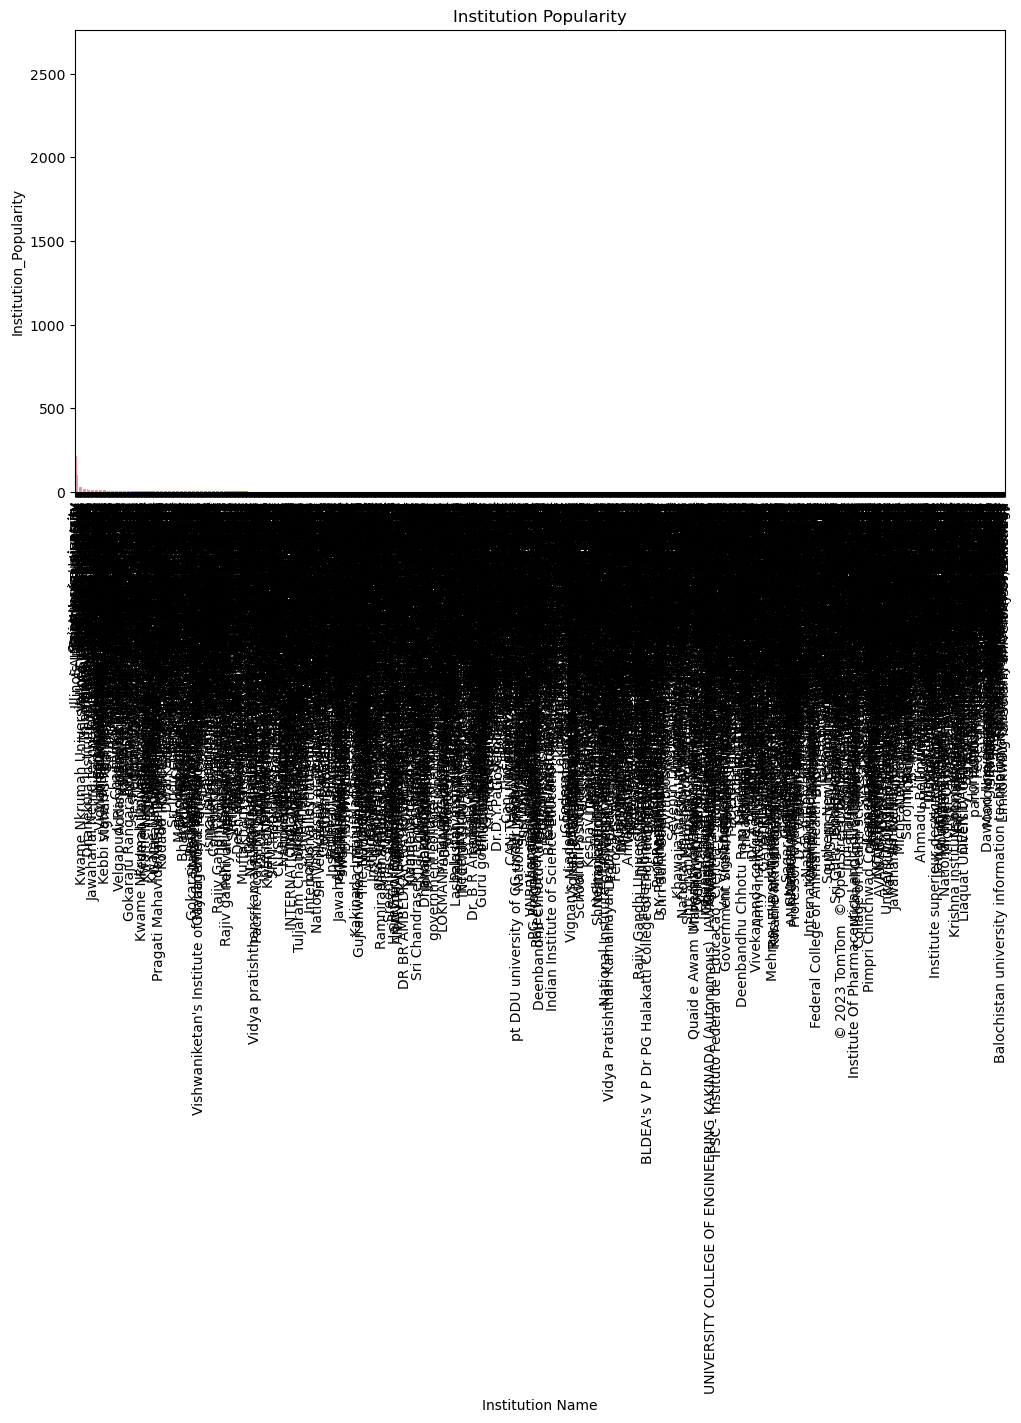

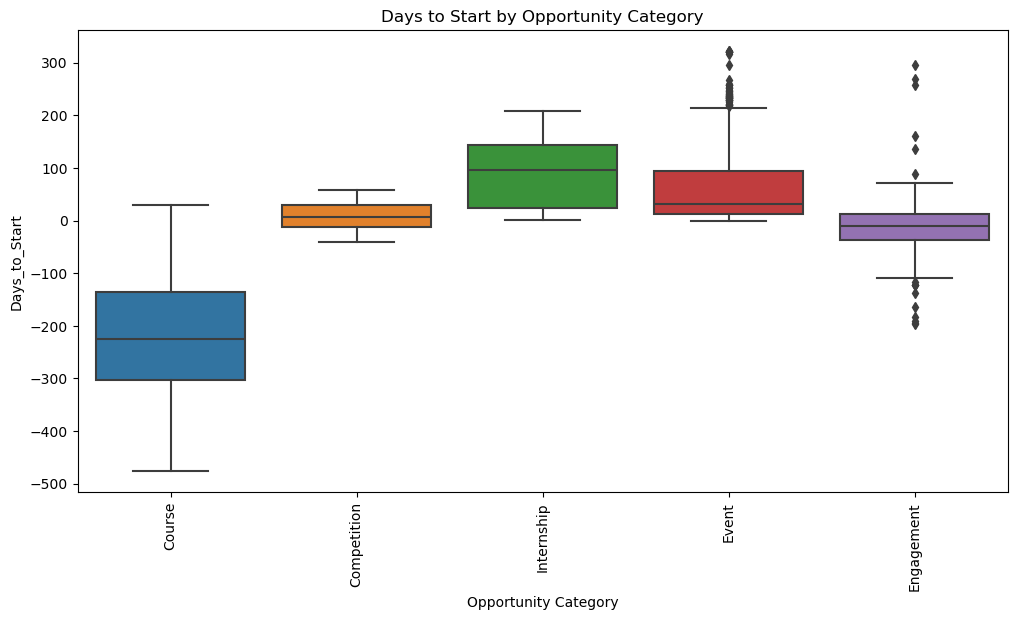

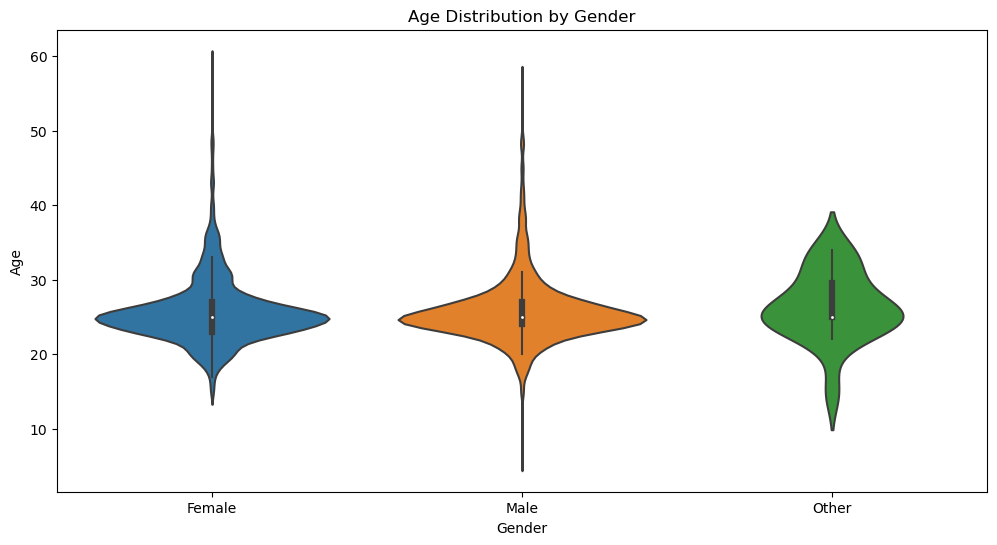

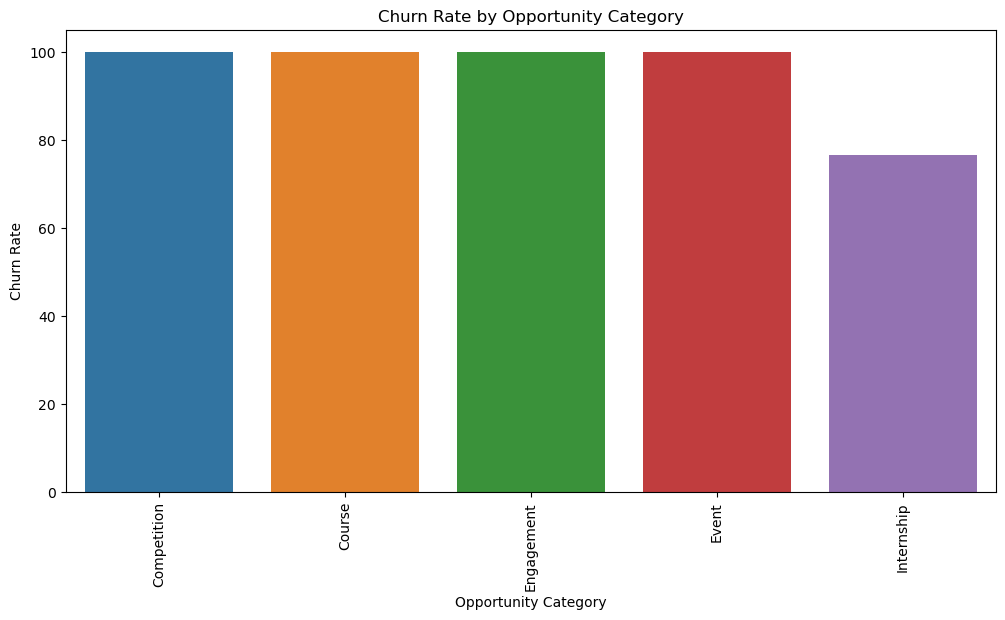

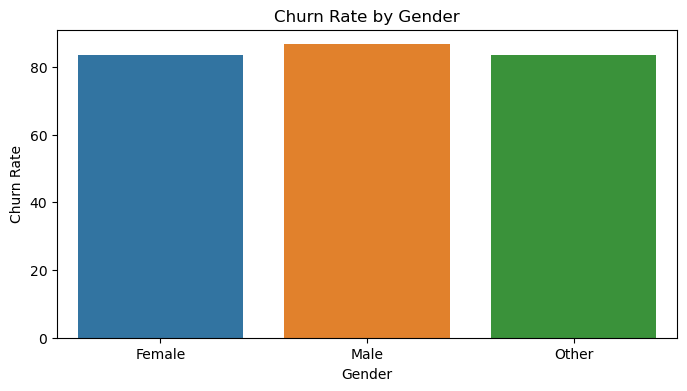

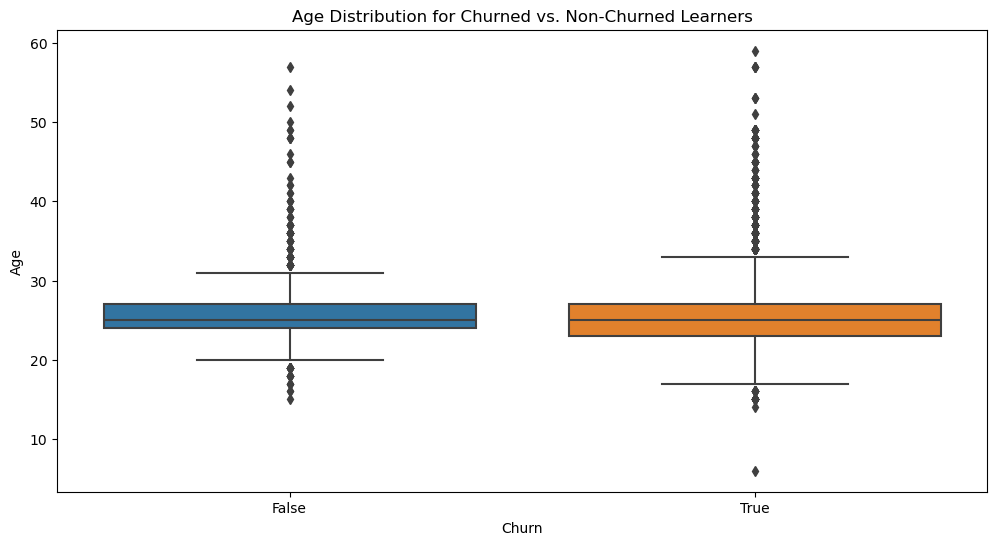

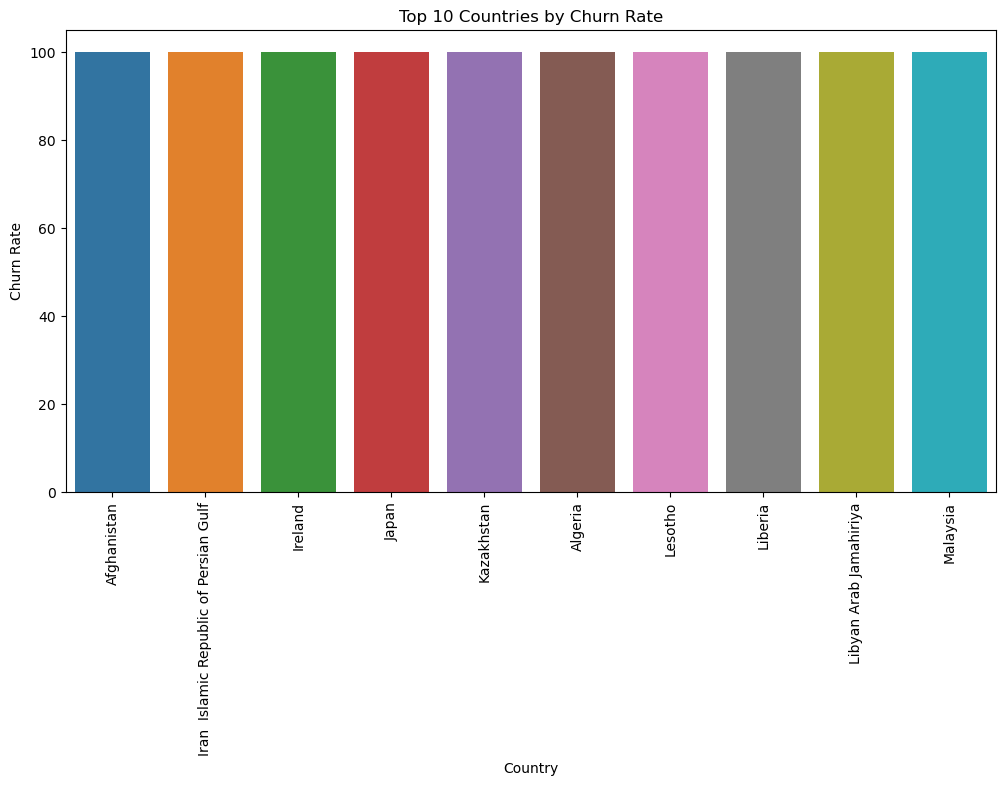

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dateutil import parser
import os

try:
    df = pd.read_csv("DataVisualization_week2_CSV.csv")
except FileNotFoundError:
    print("Error: Make sure the CSV file 'DataVisualization_week2_CSV.csv' is in the same directory as this script.")
    exit()

if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

print("--- Data Overview ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())
print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

def parse_date(date_str):
    try:
        return parser.parse(date_str)
    except (ValueError, TypeError):
        return pd.NaT

date_columns = ['Learner SignUp DateTime', 'Opportunity End Date', 'Date of Birth', 'Entry created at', 'Apply Date', 'Opportunity Start Date']
for col in date_columns:
    df[col] = df[col].apply(parse_date)

df['First Name'] = df['First Name'].str.replace(r'[^\x00-\x7F]+', '', regex=True)

print("\n--- Missing Values Before Handling ---")
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].mean())

def is_valid_age(age):
    return 10 <= age <= 100
print(df[~df['Age'].apply(is_valid_age)])

def clean_gender(gender):
    gender = str(gender).lower()
    if gender in ["male", "m"]:
        return "Male"
    elif gender in ["female", "f"]:
        return "Female"
    else:
        return "Other"
df['Gender'] = df['Gender'].apply(clean_gender)

print("\n--- Missing Values After Handling ---")
print(df.isnull().sum())

for col in ['Opportunity Category', 'Gender', 'Country', 'Institution Name', 'Status Description']:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'visualizations/{col}_countplot.png')
    plt.show()

for col in ['Age']:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'visualizations/{col}_histplot.png')
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.savefig(f'visualizations/{col}_boxplot.png')
    plt.show()

signup_trend = df.groupby('Learner SignUp DateTime').size().reset_index(name='count')
plt.figure(figsize=(12, 6))
plt.plot(signup_trend['Learner SignUp DateTime'], signup_trend['count'])
plt.title('Learner Signup Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Signups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/signup_trend.png')
plt.show()

for cat_col in ['Opportunity Category', 'Gender', 'Status Description']:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=cat_col, y='Age')
    plt.title(f'Age Distribution by {cat_col}')
    plt.xticks(rotation=90)
    plt.savefig(f'visualizations/{cat_col}_age_boxplot.png')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df, x=cat_col, y='Age')
    plt.title(f'Age Density by {cat_col}')
    plt.xticks(rotation=90)
    plt.savefig(f'visualizations/{cat_col}_age_violinplot.png')
    plt.show()

numerical_columns = ['Age']
categorical_columns = ['Opportunity Category', 'Gender', 'Status Description']
df_subset = df[numerical_columns + categorical_columns]
plt.figure(figsize=(10, 8))
sns.pairplot(df_subset, hue='Opportunity Category', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Numerical Features, Colored by Category', y=1.02)
plt.savefig('visualizations/pairplot.png')
plt.show()

correlation_matrix = df[['Age']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('visualizations/correlation_matrix.png')
plt.show()

df['Days_to_Start'] = (df['Opportunity Start Date'] - df['Apply Date']).dt.days
df['Institution_Popularity'] = df['Institution Name'].map(df['Institution Name'].value_counts())
country_counts = df['Country'].value_counts().to_dict()
df['Opportunity_ByCountry'] = df['Country'].map(country_counts)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Days_to_Start', hue='Opportunity Category')
plt.title('Scatter Plot of Age vs. Days to Start')
plt.savefig('visualizations/age_vs_days_to_start.png')
plt.show()

heatmap_data = df.groupby(['Country', 'Opportunity Category']).size().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='g')
plt.title('Heatmap of Opportunity Category by Country')
plt.savefig('visualizations/heatmap_country_opportunity.png')
plt.show()

df['Opportunity Start Month'] = df['Opportunity Start Date'].dt.to_period('M')
monthly_opportunities = df.groupby('Opportunity Start Month').size()
plt.figure(figsize=(12, 6))
monthly_opportunities.plot(kind='line')
plt.title('Monthly Opportunities Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Opportunities')
plt.savefig('visualizations/monthly_opportunities.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Institution Name', y='Institution_Popularity', order=df['Institution Name'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Institution Popularity')
plt.savefig('visualizations/institution_popularity.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Opportunity Category', y='Days_to_Start')
plt.xticks(rotation=90)
plt.title('Days to Start by Opportunity Category')
plt.savefig('visualizations/days_to_start_boxplot.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Gender', y='Age')
plt.title('Age Distribution by Gender')
plt.savefig('visualizations/age_by_gender_violinplot.png')
plt.show()

df['Churn'] = df['Opportunity End Date'].notna()
churn_rate = df['Churn'].mean() * 100
churn_by_category = df.groupby('Opportunity Category')['Churn'].mean().reset_index()
churn_by_category['Churn Rate'] = churn_by_category['Churn'] * 100
churn_by_gender = df.groupby('Gender')['Churn'].mean().reset_index()
churn_by_gender['Churn Rate'] = churn_by_gender['Churn'] * 100
churn_by_country = df.groupby('Country')['Churn'].mean().reset_index()
churn_by_country['Churn Rate'] = churn_by_country['Churn'] * 100

with open('visualizations/churn_analysis.txt', 'w') as f:
    f.write(f"--- Churn Rate: {churn_rate:.2f}% ---\n\n")
    f.write("--- Churn Analysis by Opportunity Category ---\n")
    f.write(churn_by_category.to_string() + "\n\n")
    f.write("--- Churn Analysis by Gender ---\n")
    f.write(churn_by_gender.to_string() + "\n\n")
    f.write("--- Churn Analysis by Country ---\n")
    f.write(churn_by_country.sort_values(by='Churn Rate', ascending=False).to_string() + "\n\n")

plt.figure(figsize=(12, 6))
sns.barplot(data=churn_by_category, x='Opportunity Category', y='Churn Rate')
plt.xticks(rotation=90)
plt.title('Churn Rate by Opportunity Category')
plt.savefig('visualizations/churn_by_category.png')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=churn_by_gender, x='Gender', y='Churn Rate')
plt.title('Churn Rate by Gender')
plt.savefig('visualizations/churn_by_gender.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Churn', y='Age')
plt.title('Age Distribution for Churned vs. Non-Churned Learners')
plt.savefig('visualizations/churn_by_age.png')
plt.show()

plt.figure(figsize=(12, 6))
top_10_countries = churn_by_country.sort_values(by='Churn Rate', ascending=False).head(10)
sns.barplot(data=top_10_countries, x='Country', y='Churn Rate')
plt.xticks(rotation=90)
plt.title('Top 10 Countries by Churn Rate')
plt.savefig('visualizations/churn_by_country.png')
plt.show()